In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
data = pd.read_csv(
    "../datasets/processed/day14_financial_ratios_dataset.csv"
)

print("Dataset loaded successfully!")
print("Shape:", data.shape)
print(data.head())

Dataset loaded successfully!
Shape: (110, 19)
  company ticker  year  year_end_price  dividend_per_share  dividend_yield  \
0   Apple   AAPL  2015       26.315001              0.5075            1.93   
1   Apple   AAPL  2016       28.955000              0.5575            1.93   
2   Apple   AAPL  2017       42.307499              0.6150            1.45   
3   Apple   AAPL  2018       39.435001              0.7050            1.79   
4   Apple   AAPL  2019       73.412498              0.7600            1.04   

   dividend_growth dividend_growth_category  annual_stock_return  \
0              NaN               First Year                  NaN   
1             9.85                Increased                10.03   
2            10.31                Increased                46.11   
3            14.63                Increased                -6.79   
4             7.80                Increased                86.16   

  return_category  total_return  return_volatility  average_return  \
0     

In [3]:
required_columns = [
    "ticker",
    "year",
    "dividend_yield",
    "dividend_growth",
    "total_return",
    "return_volatility"
]

for col in required_columns:
    print(col, "->", col in data.columns)

ticker -> True
year -> True
dividend_yield -> True
dividend_growth -> True
total_return -> True
return_volatility -> True


In [4]:
tax_data = data[
    [
        "ticker",
        "year",
        "dividend_yield",
        "dividend_growth",
        "total_return",
        "return_volatility"
    ]
].copy()

print("Tax/Clientele dataset shape:", tax_data.shape)
print(tax_data.head())

Tax/Clientele dataset shape: (110, 6)
  ticker  year  dividend_yield  dividend_growth  total_return  \
0   AAPL  2015            1.93              NaN           NaN   
1   AAPL  2016            1.93             9.85         11.96   
2   AAPL  2017            1.45            10.31         47.56   
3   AAPL  2018            1.79            14.63         -5.00   
4   AAPL  2019            1.04             7.80         87.20   

   return_volatility  
0              36.16  
1              36.16  
2              36.16  
3              36.16  
4              36.16  


In [5]:
print("Missing values:")
print(tax_data.isnull().sum())

Missing values:
ticker                0
year                  0
dividend_yield        0
dividend_growth      10
total_return         10
return_volatility     0
dtype: int64


In [6]:
analysis_data = tax_data.dropna(
    subset=[
        "dividend_yield",
        "dividend_growth",
        "total_return",
        "return_volatility"
    ]
).copy()

print("Complete analysis rows:", analysis_data.shape)

Complete analysis rows: (100, 6)


In [7]:
yield_return_corr = analysis_data[
    ["dividend_yield", "total_return"]
].corr().iloc[0, 1]

yield_volatility_corr = analysis_data[
    ["dividend_yield", "return_volatility"]
].corr().iloc[0, 1]

growth_return_corr = analysis_data[
    ["dividend_growth", "total_return"]
].corr().iloc[0, 1]

growth_volatility_corr = analysis_data[
    ["dividend_growth", "return_volatility"]
].corr().iloc[0, 1]

print("Dividend Yield vs Total Return:",
      round(yield_return_corr, 4))

print("Dividend Yield vs Return Volatility:",
      round(yield_volatility_corr, 4))

print("Dividend Growth vs Total Return:",
      round(growth_return_corr, 4))

print("Dividend Growth vs Return Volatility:",
      round(growth_volatility_corr, 4))

Dividend Yield vs Total Return: -0.4089
Dividend Yield vs Return Volatility: -0.3027
Dividend Growth vs Total Return: 0.1139
Dividend Growth vs Return Volatility: 0.1365


In [8]:
tax_results = pd.DataFrame({
    "Relationship": [
        "Dividend Yield vs Total Return",
        "Dividend Yield vs Return Volatility",
        "Dividend Growth vs Total Return",
        "Dividend Growth vs Return Volatility"
    ],
    "Correlation": [
        yield_return_corr,
        yield_volatility_corr,
        growth_return_corr,
        growth_volatility_corr
    ]
})

tax_results["Absolute_Correlation"] = (
    tax_results["Correlation"].abs()
)

print(tax_results.round(4))

                           Relationship  Correlation  Absolute_Correlation
0        Dividend Yield vs Total Return      -0.4089                0.4089
1   Dividend Yield vs Return Volatility      -0.3027                0.3027
2       Dividend Growth vs Total Return       0.1139                0.1139
3  Dividend Growth vs Return Volatility       0.1365                0.1365


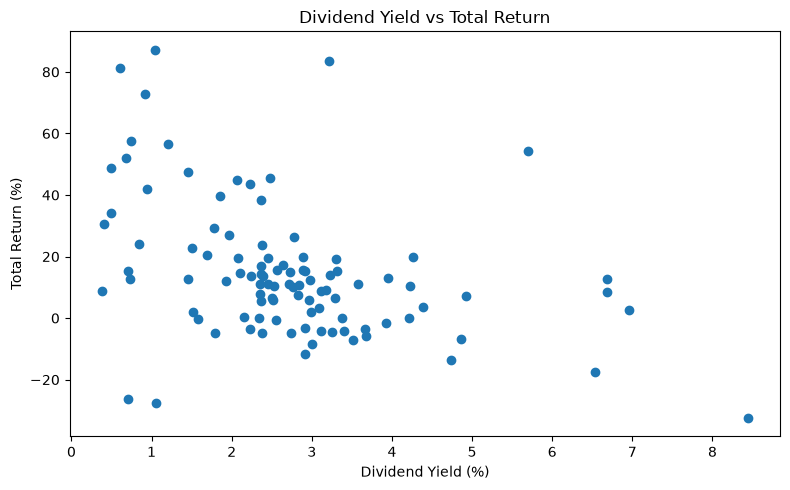

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_yield"],
    analysis_data["total_return"]
)

plt.xlabel("Dividend Yield (%)")
plt.ylabel("Total Return (%)")
plt.title("Dividend Yield vs Total Return")

plt.tight_layout()
plt.show()

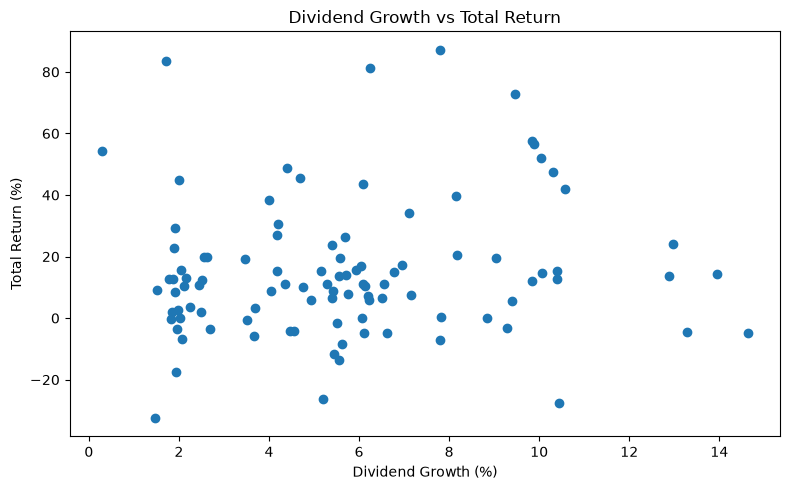

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_growth"],
    analysis_data["total_return"]
)

plt.xlabel("Dividend Growth (%)")
plt.ylabel("Total Return (%)")
plt.title("Dividend Growth vs Total Return")

plt.tight_layout()
plt.show()

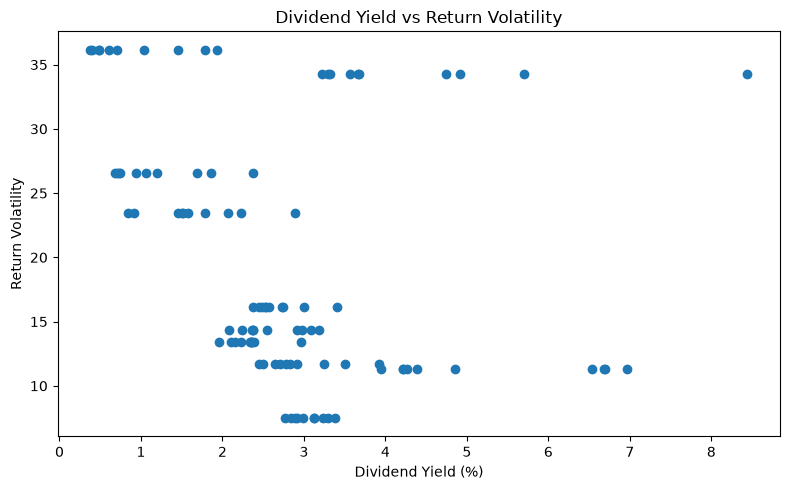

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_yield"],
    analysis_data["return_volatility"]
)

plt.xlabel("Dividend Yield (%)")
plt.ylabel("Return Volatility")
plt.title("Dividend Yield vs Return Volatility")

plt.tight_layout()
plt.show()

In [12]:
tax_results.to_csv(
    "../datasets/processed/day25_tax_clientele_results.csv",
    index=False
)

print("Day 25 Tax/Clientele results saved successfully!")

Day 25 Tax/Clientele results saved successfully!


In [13]:
import os

print(
    "CSV exists:",
    os.path.exists(
        "../datasets/processed/day25_tax_clientele_results.csv"
    )
)

CSV exists: True


In [14]:
print(tax_results.round(4))

                           Relationship  Correlation  Absolute_Correlation
0        Dividend Yield vs Total Return      -0.4089                0.4089
1   Dividend Yield vs Return Volatility      -0.3027                0.3027
2       Dividend Growth vs Total Return       0.1139                0.1139
3  Dividend Growth vs Return Volatility       0.1365                0.1365
